# Medical Data Visualizer

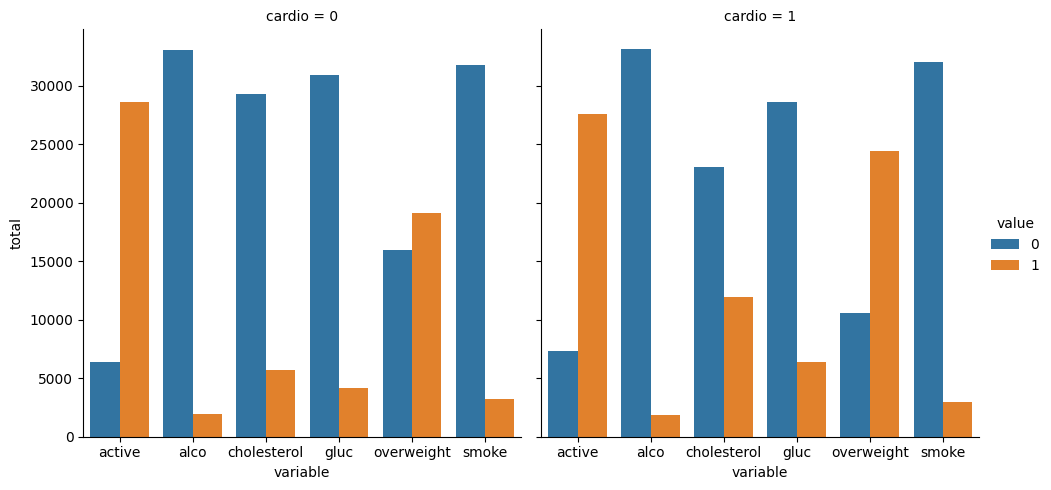

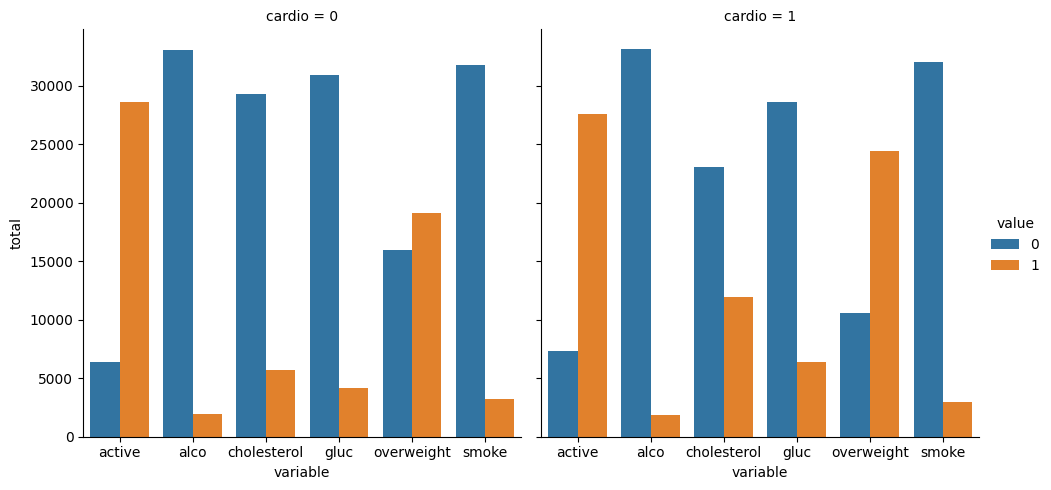

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data
df = pd.read_csv('/medical_examination.csv')

# 2. Add 'overweight' column
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
df['overweight'] = (df['BMI'] > 25).astype(int)
df.drop(columns=['BMI'], inplace=True)  # Drop temporary BMI column

# 3. Normalize 'cholesterol' and 'gluc'
df['cholesterol'] = (df['cholesterol'] > 1).astype(int)
df['gluc'] = (df['gluc'] > 1).astype(int)

# 4. Draw Categorical Plot
def draw_cat_plot():
    # 5. Melt the DataFrame
    df_cat = pd.melt(
        df,
        id_vars=['cardio'],
        value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight']
    )

    # 6. Group and reformat the data
    df_cat = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='total')

    # 7. Draw the catplot
    fig = sns.catplot(
        x='variable', y='total', hue='value', col='cardio',
        data=df_cat, kind='bar', height=5, aspect=1
    ).fig

    # 8. Save the figure
    fig.savefig('catplot.png')
    return fig

# 10. Draw Heat Map
def draw_heat_map():
    # 11. Clean the data
    df_heat = df[
        (df['ap_lo'] <= df['ap_hi']) &
        (df['height'] >= df['height'].quantile(0.025)) &
        (df['height'] <= df['height'].quantile(0.975)) &
        (df['weight'] >= df['weight'].quantile(0.025)) &
        (df['weight'] <= df['weight'].quantile(0.975))
    ]

    # 12. Calculate the correlation matrix
    corr = df_heat.corr()

    # 13. Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # 14. Set up the matplotlib figure
    fig, ax = plt.subplots(figsize=(12, 8))

    # 15. Draw the heatmap
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".1f", cmap='coolwarm',
        vmax=0.3, center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.5}
    )

    # 16. Save the figure
    fig.savefig('heatmap.png')
    return fig


draw_cat_plot()

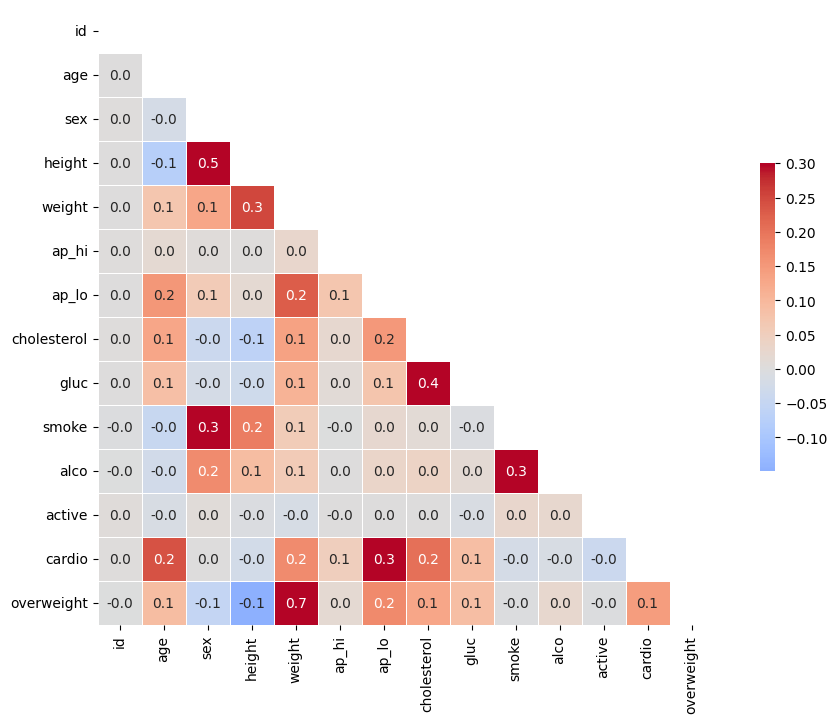

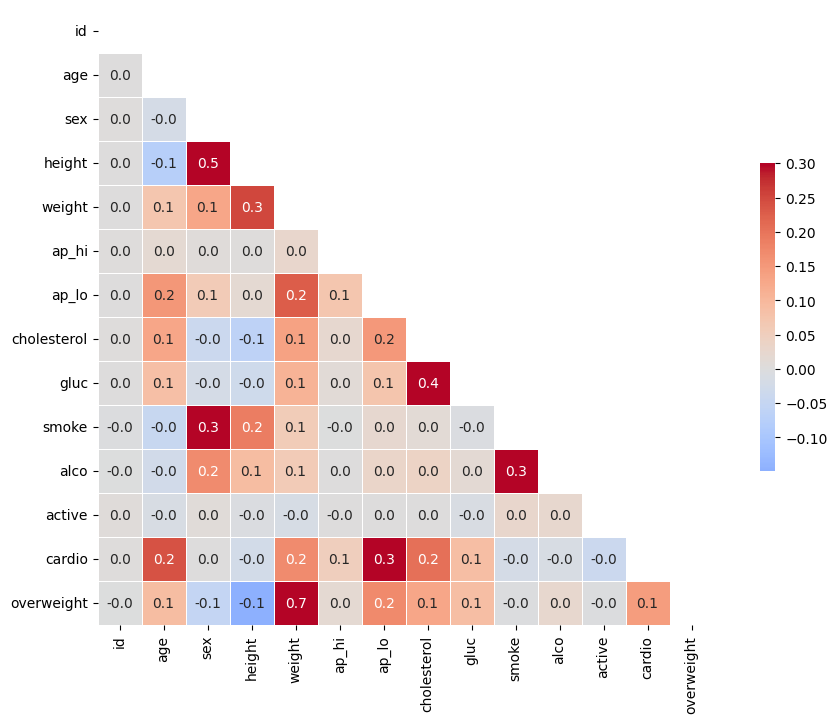

In [ ]:
draw_heat_map()